<a href="https://colab.research.google.com/github/ArthurWgirao/ArthurWgirao/blob/main/Trabalho_Aplicado_Infer%C3%AAncia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# # Análise Inferencial

# Existe diferença na média de gols entre partidas da fase de grupos e partidas eliminatórias da Copa do Mundo FIFA?

**Disciplina:** Análise Inferencial

Alunos: Vinícius Carvalho - 554220 / Arthur Wagner Girão Muniz - 538043

---

# 1. Introdução

A Copa do Mundo FIFA é o torneio de futebol de seleções mais importante do mundo, reunindo equipes de diferentes continentes e níveis técnicos em uma competição disputada a cada quatro anos. Durante o torneio, as seleções passam inicialmente por uma fase de grupos, onde um eventual resultado negativo ainda pode ser recuperado nas partidas seguintes. Posteriormente, inicia-se a fase eliminatória (mata-mata), na qual uma derrota implica a eliminação imediata da equipe.

Essa diferença no formato da competição levanta uma questão interessante do ponto de vista estatístico: **será que partidas eliminatórias apresentam menos gols do que partidas da fase de grupos?**

Sob a perspectiva esportiva, espera-se que equipes adotem estratégias mais conservadoras durante jogos eliminatórios, uma vez que o risco associado à derrota é significativamente maior. Caso essa hipótese seja verdadeira, espera-se observar uma redução na média de gols marcados nas partidas do mata-mata quando comparadas às partidas da fase inicial.

A Estatística Inferencial fornece ferramentas adequadas para responder essa questão por meio da análise de dados históricos das Copas do Mundo. Neste trabalho será utilizado um conjunto de dados contendo informações detalhadas das partidas oficiais do torneio, permitindo verificar, por meio de testes estatísticos, se a diferença observada entre as médias pode ser considerada estatisticamente significativa.

---

## Objetivo Geral

Verificar se existe diferença estatisticamente significativa entre a média de gols das partidas da fase de grupos e das partidas eliminatórias da Copa do Mundo FIFA.

## Objetivos Específicos

- Explorar o conjunto de dados;
- Preparar os dados para análise;
- Calcular estatísticas descritivas;
- Visualizar a distribuição da quantidade de gols;
- Verificar os pressupostos necessários para aplicação dos testes estatísticos;
- Comparar as médias entre as duas fases da competição;
- Interpretar os resultados obtidos.

---

#  Hipóteses

Seja

- μGrupo = média de gols na fase de grupos

- μMataMata = média de gols nas fases eliminatórias

Deseja-se testar as seguintes hipóteses:

### Hipótese nula (H₀)

A média de gols é igual entre as duas fases da competição.

\[
H_0: mu_{Grupo}= mu_{MataMata}
\]

### Hipótese alternativa (H₁)

As partidas eliminatórias apresentam menor média de gols.

\[
H_1: mu_{Grupo}> mu_{MataMata}
\]

Será adotado nível de significância de 5%.

alpha=0.05

# Bibliotecas Utilizadas:

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10,6)

# Leitura do conjunto de dados

O conjunto de dados utilizado contém informações detalhadas sobre partidas da Copa do Mundo FIFA.

Inicialmente será realizada a leitura do arquivo JSON contendo todas as partidas.

In [ ]:
import json

with open("matchDetails.json", "r", encoding="utf-8") as f:
    dados = json.load(f)

print(type(dados))
print(dados.keys())

<class 'dict'>
dict_keys(['matchDetails'])


In [ ]:
# Conversão da lista de partidas para DataFrame

df = pd.json_normalize(dados["matchDetails"])

# Conhecendo o conjunto de dados

Antes de realizar qualquer análise estatística, é importante compreender a estrutura do conjunto de dados.

Nesta etapa serão apresentados:

- número de partidas;
- número de variáveis;
- tipos de dados;
- valores ausentes;
- principais atributos disponíveis.

In [ ]:
print(f"Número de partidas : {df.shape[0]}")
print(f"Número de variáveis: {df.shape[1]}")

Número de partidas : 900
Número de variáveis: 45


In [ ]:
df.head()

,idMatch,idCompetition,idStage,idGroup,stageName,groupName,date,localDate,matchDay,stadiumName,...,homeTeam.idTeam,homeTeam.score,homeTeam.teamName,homeTeam.teamType,homeTeam.players,homeTeam.coaches,homeTeam.substitutions,homeTeam.goals,homeTeam.bookings,homeTeam.tactics
0,1096,0,201,401,Group Matches,Group 1,1930-07-13T18:00:00Z,1930-07-13T15:00:00Z,None,Pocitos,...,43946,4,France,1,"[{'playerId': '58899', 'name': 'Alex THEPOT', ...","[{'coachId': '61612', 'countryId': 'FRA', 'ali...",[],"[{'playerId': '52726', 'playerName': 'Marcel L...",[],None
1,1090,0,201,404,Group Matches,Group 4,1930-07-13T18:00:00Z,1930-07-13T15:00:00Z,None,Parque Central,...,43921,3,United States,1,"[{'playerId': '48705', 'name': 'Jimmy DOUGLAS'...","[{'coachId': '182280', 'countryId': 'USA', 'al...",[],"[{'playerId': '53957', 'playerName': 'Bart McG...",[],None
2,1093,0,201,402,Group Matches,Group 2,1930-07-14T15:45:00Z,1930-07-14T12:45:00Z,None,Parque Central,...,43975,2,Yugoslavia,1,"[{'playerId': '51407', 'name': 'Milovan JAKSIC...","[{'coachId': '61691', 'countryId': 'YUG', 'ali...",[],"[{'playerId': '46364', 'playerName': 'Ivica BE...",[],None
3,1098,0,201,403,Group Matches,Group 3,1930-07-14T17:50:00Z,1930-07-14T14:50:00Z,None,Pocitos,...,43964,3,Romania,1,"[{'playerId': '52738', 'name': 'Ion LAPUSNEANU...","[{'coachId': '182311', 'countryId': 'ROU', 'al...",[],"[{'playerId': '58384', 'playerName': 'Constant...",[],None
4,1085,0,201,401,Group Matches,Group 1,1930-07-15T19:00:00Z,1930-07-15T16:00:00Z,None,Parque Central,...,43922,1,Argentina,1,"[{'playerId': '46826', 'name': 'Angel BOSSIO',...","[{'coachId': '203462', 'countryId': 'ARG', 'al...",[],"[{'playerId': '174777', 'playerName': 'Luis MO...",[],None


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   idMatch                 900 non-null    object 
 1   idCompetition           900 non-null    int64  
 2   idStage                 900 non-null    object 
 3   idGroup                 664 non-null    object 
 4   stageName               900 non-null    object 
 5   groupName               664 non-null    object 
 6   date                    900 non-null    object 
 7   localDate               900 non-null    object 
 8   matchDay                64 non-null     object 
 9   stadiumName             900 non-null    object 
 10  cityName                900 non-null    object 
 11  winner                  731 non-null    object 
 12  awayTeamPenaltyScore    90 non-null     float64
 13  homeTeamPenaltyScore    90 non-null     float64
 14  aggregateAwayTeamScore  0 non-null      ob

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
idMatch,900,900,300331552,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
idCompetition,900.0,NaN,NaN,NaN,12.346667,5.53157,0.0,8.0,13.0,17.0,20.0
idStage,900,107,10172,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
idGroup,664,116,487,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stageName,900,13,Group Matches,388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
groupName,664,14,Group B,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,900,656,1934-05-27T14:30:00Z,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
localDate,900,661,1934-05-27T16:30:00Z,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
matchDay,64,3,1,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stadiumName,900,192,Estadio Azteca,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
matchNumber,900
placeholderA,900
placeholderB,900
aggregateHomeTeamScore,900
aggregateAwayTeamScore,900
confederation,900
homeTeam.tactics,836
awayTeam.tactics,836
matchDay,836
awayTeamPenaltyScore,810


Observa-se que o conjunto de dados contém diversas informações sobre cada partida, incluindo dados referentes às equipes, árbitros, cartões, substituições, gols, estádio e outras características do jogo.

Entretanto, para responder à hipótese proposta neste trabalho, apenas uma pequena parcela dessas variáveis será necessária.

# Seleção das variáveis de interesse

O objetivo deste estudo é comparar a média de gols entre partidas da fase de grupos e partidas eliminatórias.

Assim, serão utilizadas apenas as seguintes variáveis:

- `stageName`
- `homeTeam.score`
- `awayTeam.score`

In [ ]:
dados = df[
    [
        "stageName",
        "homeTeam.score",
        "awayTeam.score"
    ]
].copy()

dados.head()

,stageName,homeTeam.score,awayTeam.score
0,Group Matches,4,1
1,Group Matches,3,0
2,Group Matches,2,1
3,Group Matches,3,1
4,Group Matches,1,0


# Tratamento dos dados

Antes da análise estatística, é necessário verificar a existência de registros incompletos.

In [ ]:
dados.isnull().sum()

,0
stageName,0
homeTeam.score,0
awayTeam.score,0


In [ ]:
dados = dados.dropna()

print(f"Número de partidas após limpeza: {len(dados)}")

Número de partidas após limpeza: 900


# Criação da variável resposta

A variável de interesse deste estudo é o **número total de gols marcados em cada partida**.

Ela será obtida pela soma dos gols das duas equipes.

In [ ]:
dados["total_goals"] = (
    dados["homeTeam.score"] +
    dados["awayTeam.score"]
)

# Classificação das partidas

A variável `stageName` apresenta diversas nomenclaturas para representar as fases da competição.

Para facilitar a comparação estatística, essas fases serão agrupadas em duas categorias:

- **Grupo**
- **Mata-mata**

Inicialmente, vamos verificar todos os valores distintos presentes na variável.

In [ ]:
sorted(dados["stageName"].unique())

['1st Round',
 'Final',
 'Final Round',
 'First stage',
 'Group Matches',
 'Group Stage',
 'Match for third place',
 'Play-off for third place',
 'Preliminary Round',
 'Quarter-final',
 'Round of 16',
 'Second Round',
 'Semi-final']

#  Classificação das fases da competição

Como a Copa do Mundo sofreu alterações em seu formato ao longo das décadas, diferentes nomenclaturas foram utilizadas para representar fases equivalentes.

Para padronizar a análise, as fases serão agrupadas em duas categorias:

- **Grupo**
- **Mata-mata**

As partidas válidas pela disputa do terceiro lugar serão removidas da análise por apresentarem características competitivas distintas das demais fases eliminatórias.

In [ ]:
grupos = [
    "Preliminary Round",
    "1st Round",
    "First stage",
    "Second Round",
    "Final Round",
    "Group Matches",
    "Group Stage"
]

mata_mata = [
    "Round of 16",
    "Quarter-final",
    "Semi-final",
    "Final"
]

dados = dados[dados["stageName"].isin(grupos + mata_mata)].copy()

dados["tipo_fase"] = np.where(
    dados["stageName"].isin(grupos),
    "Grupo",
    "Mata-mata"
)

In [ ]:
dados.head()

,stageName,homeTeam.score,awayTeam.score,total_goals,tipo_fase
0,Group Matches,4,1,5,Grupo
1,Group Matches,3,0,3,Grupo
2,Group Matches,2,1,3,Grupo
3,Group Matches,3,1,4,Grupo
4,Group Matches,1,0,1,Grupo


In [ ]:
dados["tipo_fase"].value_counts()

,count
tipo_fase,
Grupo,687
Mata-mata,194


Observa-se que todas as partidas foram classificadas em apenas duas categorias, permitindo comparar diretamente o comportamento da quantidade de gols entre elas.

#  Estatística Descritiva

Antes da aplicação de qualquer teste de hipótese, é importante realizar uma análise exploratória dos dados.

Nesta etapa serão calculadas medidas de tendência central e dispersão para cada grupo.

In [ ]:
estatisticas = (
    dados
    .groupby("tipo_fase")["total_goals"]
    .agg(
        Quantidade="count",
        Média="mean",
        Mediana="median",
        Desvio_Padrão="std",
        Variância="var",
        Mínimo="min",
        Máximo="max"
    )
)

estatisticas.round(2)

,Quantidade,Média,Mediana,Desvio_Padrão,Variância,Mínimo,Máximo
tipo_fase,,,,,,,
Grupo,687,2.77,3.0,1.90,3.61,0,11
Mata-mata,194,2.96,3.0,2.01,4.03,0,12


In [ ]:
dados.groupby("tipo_fase")["total_goals"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
tipo_fase,,,,,,,,
Grupo,687.0,2.77,1.90,0.0,1.0,3.0,4.0,11.0
Mata-mata,194.0,2.96,2.01,0.0,1.0,3.0,4.0,12.0


A Tabela apresenta as principais estatísticas descritivas da variável **total de gols**, comparando as partidas da fase de grupos e do mata-mata.

Foram analisadas **687 partidas da fase de grupos** e **194 partidas eliminatórias**. A média de gols foi de **2,77** na fase de grupos e **2,96** no mata-mata, indicando, de forma preliminar, um comportamento contrário à hipótese inicial deste estudo, que previa menos gols nas fases eliminatórias.

As duas categorias apresentaram **mediana igual a 3 gols** e valores de desvio padrão bastante próximos (1,90 e 2,01), sugerindo distribuições semelhantes quanto à dispersão. Além disso, ambas registraram partidas sem gols e partidas com elevado número de gols, com máximos de 11 e 12 gols, respectivamente.

Embora exista uma pequena diferença entre as médias observadas, apenas a aplicação de um teste de hipótese permitirá determinar se essa diferença é estatisticamente significativa ou se pode ser atribuída à variabilidade natural dos dados.

#  Distribuição da quantidade de gols

Inicialmente será analisada a distribuição da variável **Total de Gols**.

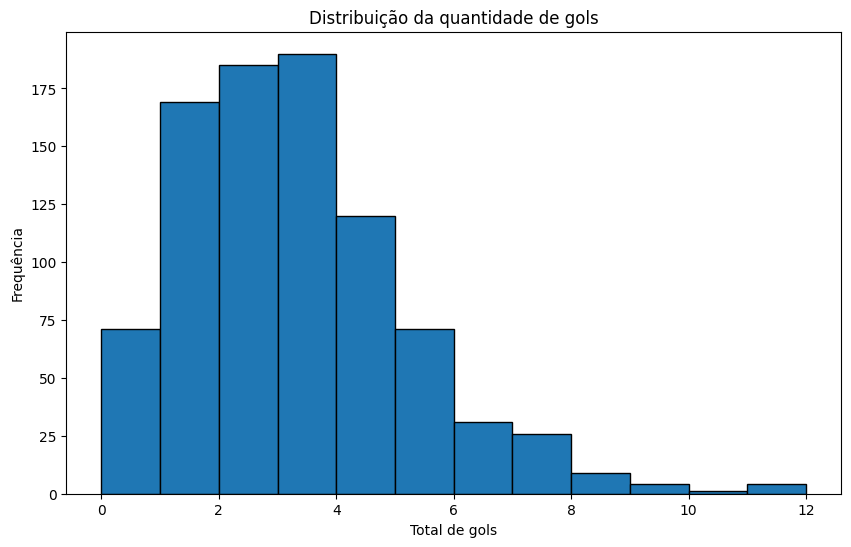

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    dados["total_goals"],
    bins=12,
    edgecolor="black"
)

plt.xlabel("Total de gols")
plt.ylabel("Frequência")
plt.title("Distribuição da quantidade de gols")

plt.show()

O histograma mostra a distribuição da quantidade total de gols considerando todas as partidas analisadas. Observa-se uma concentração significativa entre **2 e 4 gols por jogo**, indicando que esse é o intervalo de resultados mais frequente nas Copas do Mundo.

À medida que o número de gols aumenta, a frequência de partidas diminui gradualmente, formando uma distribuição **assimétrica à direita**. Jogos com placares muito elevados (acima de 8 gols) são pouco frequentes e representam casos excepcionais dentro da amostra.

Essa característica sugere que a variável **total de gols** não segue visualmente uma distribuição perfeitamente normal. Entretanto, essa impressão será confirmada ou refutada por meio do teste de normalidade na etapa seguinte, o que auxiliará na escolha do teste estatístico mais adequado para comparar as duas fases da competição.

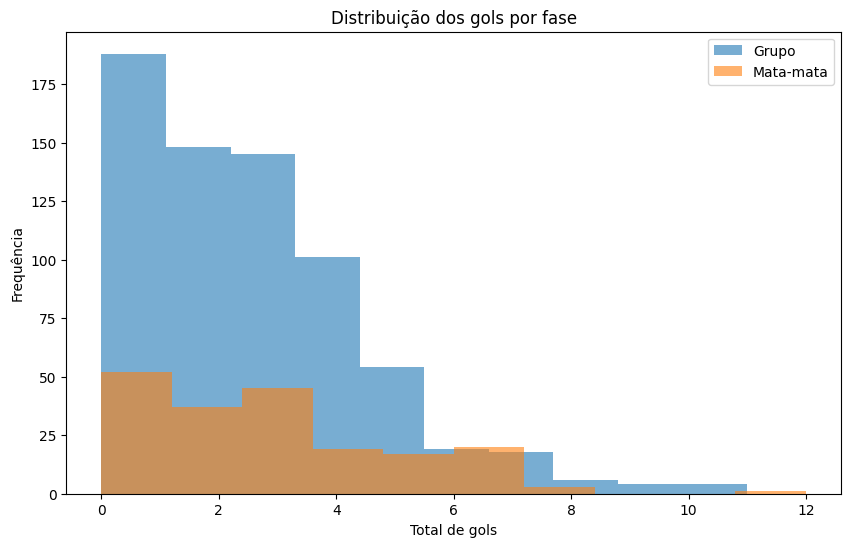

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

for fase in ["Grupo","Mata-mata"]:

    subset = dados[dados["tipo_fase"]==fase]

    ax.hist(
        subset["total_goals"],
        bins=10,
        alpha=0.6,
        label=fase
    )

ax.set_xlabel("Total de gols")
ax.set_ylabel("Frequência")

ax.set_title("Distribuição dos gols por fase")

ax.legend()

plt.show()

A Figura apresenta a distribuição da quantidade de gols separadamente para as partidas da **fase de grupos** e do **mata-mata**. Em ambas as categorias, a maior concentração de partidas ocorre entre **1 e 4 gols**, indicando um comportamento semelhante na maior parte dos jogos.

Visualmente, observa-se que as duas distribuições possuem formato parecido, embora as partidas eliminatórias aparentem apresentar uma frequência relativamente maior de jogos com **5 ou mais gols**. Esse comportamento está de acordo com a análise descritiva anterior, na qual o mata-mata apresentou uma média de gols ligeiramente superior à da fase de grupos.

Apesar dessas diferenças aparentes, a sobreposição das distribuições mostra que elas compartilham características muito semelhantes. Dessa forma, a comparação visual, por si só, não permite concluir se existe uma diferença estatisticamente significativa entre as fases, tornando necessária a aplicação de testes inferenciais nas próximas etapas.

# Comparação da distribuição dos gols

O boxplot resume informações importantes como mediana, quartis, dispersão e valores extremos, permitindo comparar visualmente as distribuições.

<Figure size 800x600 with 0 Axes>

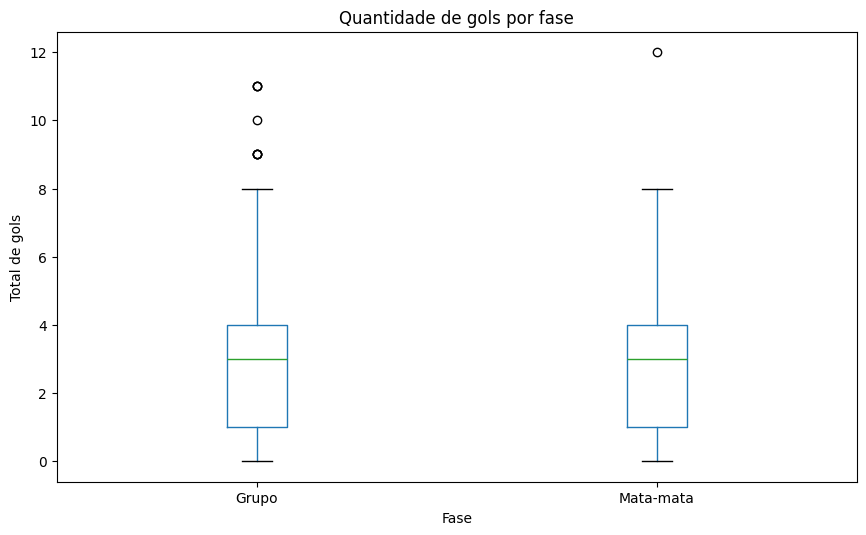

In [ ]:
plt.figure(figsize=(8,6))

dados.boxplot(
    column="total_goals",
    by="tipo_fase",
    grid=False
)

plt.title("Quantidade de gols por fase")

plt.suptitle("")

plt.xlabel("Fase")

plt.ylabel("Total de gols")

plt.show()

A Figura apresenta o boxplot da quantidade de gols nas partidas da fase de grupos e do mata-mata. Observa-se que ambas as distribuições possuem **mediana igual a 3 gols** e intervalos interquartis bastante semelhantes, indicando um comportamento consistente entre as duas fases da competição.

A dispersão dos dados também é próxima, embora o mata-mata apresente um valor máximo ligeiramente superior, com uma partida registrando **12 gols**, enquanto a fase de grupos apresenta valores extremos de até **11 gols**. Além disso, observa-se a presença de **outliers** em ambas as categorias, evidenciando que partidas com muitos gols são eventos raros, porém possíveis em qualquer fase do torneio.

De modo geral, o boxplot reforça a percepção obtida na análise descritiva: as distribuições são bastante semelhantes e as diferenças visuais observadas parecem discretas. Assim, torna-se necessário recorrer aos testes de hipótese para verificar se a diferença entre as médias é estatisticamente significativa.

#  Comparação das médias

A seguir será apresentada a média de gols observada em cada grupo.

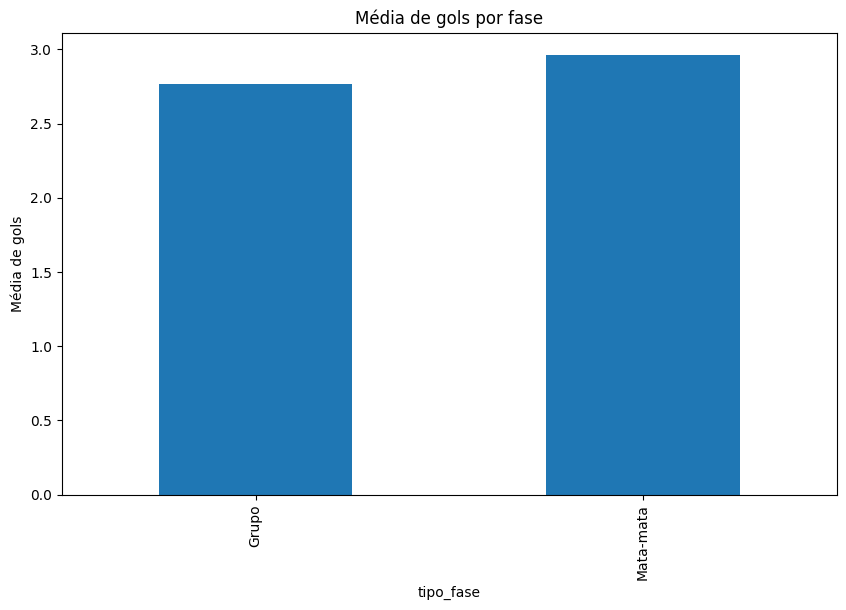

In [ ]:
media = (
    dados
    .groupby("tipo_fase")["total_goals"]
    .mean()
)

media.plot(kind="bar")

plt.ylabel("Média de gols")

plt.title("Média de gols por fase")

plt.show()

In [ ]:
media.round(2)

,total_goals
tipo_fase,
Grupo,2.77
Mata-mata,2.96


O gráfico de barras apresenta a média de gols por partida para as duas fases da competição: **fase de grupos** e **mata-mata**. Observa-se que a média de gols na fase de grupos é ligeiramente inferior à do mata-mata, com uma diferença aparente entre as duas barras.

Embora os valores médios indiquem que as partidas eliminatórias tendem a ter um número um pouco maior de gols, essa diferença visual não é suficiente para afirmar que existe uma distinção significativa entre as fases. A sobreposição dos intervalos de confiança (se disponíveis) ou a variabilidade dos dados poderiam reforçar ou relativizar essa impressão.

Esse resultado está alinhado com o que foi observado na distribuição anterior, em que o mata-mata apresentou frequência relativamente maior de jogos com 5 ou mais gols. Contudo, assim como na análise descritiva, a comparação das médias por si só não permite concluir sobre a existência de diferença estatisticamente relevante.

Dessa forma, torna-se necessário recorrer a um teste de hipótese (como o teste t ou Mann-Whitney, conforme os resultados do teste de normalidade) para verificar se a diferença observada entre as médias é estatisticamente significativa ou se pode ser atribuída ao acaso.

# Estimação Intervalar

Além da estimativa pontual, é importante construir intervalos de confiança para estimar a média populacional de gols em cada fase da competição.

Neste trabalho, foram construídos **intervalos de confiança de 95%**, fornecendo uma faixa de valores plausíveis para a verdadeira média de gols.

In [ ]:
from scipy.stats import t

def intervalo_confianca(x, confianca=0.95):

    n = len(x)

    media = np.mean(x)

    erro = (
        t.ppf((1 + confianca) / 2, n - 1)
        * np.std(x, ddof=1)
        / np.sqrt(n)
    )

    return pd.Series({
        "Média": media,
        "Limite Inferior": media - erro,
        "Limite Superior": media + erro
    })

ic = (
    dados
    .groupby("tipo_fase")["total_goals"]
    .apply(intervalo_confianca)
    .unstack()
)

ic.round(3)

,Média,Limite Inferior,Limite Superior
tipo_fase,,,
Grupo,2.766,2.623,2.908
Mata-mata,2.964,2.679,3.248


Os intervalos de confiança de 95% estimam que a média de gols por partida na fase de grupos esteja entre **2,623 e 2,908**, enquanto para as partidas de mata-mata a média estimada situa-se entre **2,679 e 3,248** gols.

Observa-se uma **sobreposição considerável** entre os intervalos de confiança das duas fases, indicando que a diferença observada entre as médias pode ser explicada pela variabilidade amostral. Dessa forma, os intervalos não fornecem evidências suficientes para sugerir uma diferença consistente na quantidade média de gols entre as partidas da fase de grupos e do mata-mata.

Embora a média estimada para o mata-mata seja ligeiramente superior, a ampla interseção entre os intervalos reforça a necessidade da aplicação de um teste de hipótese para verificar se essa diferença é estatisticamente significativa.

# Verificação dos pressupostos

Antes da aplicação de um teste para comparação entre dois grupos, é necessário verificar se os dados atendem aos pressupostos exigidos pelo teste t para amostras independentes.

Inicialmente será avaliada a normalidade da variável **total de gols** em cada grupo por meio do teste de **Shapiro-Wilk**. Em seguida, será verificada a homogeneidade das variâncias utilizando o teste de **Levene**.

Os resultados desses testes determinarão qual procedimento inferencial será mais adequado para comparar as duas fases da competição.

In [ ]:
grupo = dados[dados["tipo_fase"]=="Grupo"]["total_goals"]

mata = dados[dados["tipo_fase"]=="Mata-mata"]["total_goals"]

shapiro_grupo = shapiro(grupo)

shapiro_mata = shapiro(mata)

print("Grupo")
print(shapiro_grupo)

print()

print("Mata-mata")
print(shapiro_mata)

Grupo
ShapiroResult(statistic=np.float64(0.9211901415750293), pvalue=np.float64(1.8121523049245342e-18))

Mata-mata
ShapiroResult(statistic=np.float64(0.9171199332921391), pvalue=np.float64(5.438240066611028e-09))


Considerando um nível de significância de **5%**, interpreta-se o resultado do teste da seguinte forma:

- **p > 0,05:** não há evidências para rejeitar a hipótese de normalidade;
- **p ≤ 0,05:** rejeita-se a hipótese de normalidade.

A interpretação específica será realizada a partir dos valores obtidos na execução do teste.

Os resultados do teste de Shapiro-Wilk indicam valores de **p inferiores a 0,05** tanto para as partidas da fase de grupos (**p ≈ 1,81 × 10⁻¹⁸**) quanto para as partidas de mata-mata (**p ≈ 5,44 × 10⁻⁹**). Dessa forma, rejeita-se a hipótese nula de normalidade para ambos os grupos.

Esses resultados sugerem que a distribuição da variável **total de gols** não segue uma distribuição normal em nenhuma das duas fases da competição. Essa conclusão também é coerente com a análise visual dos histogramas, que evidenciaram uma distribuição assimétrica à direita, com poucos jogos apresentando um número muito elevado de gols.

Assim, o pressuposto de normalidade necessário para a aplicação do teste *t* não é atendido, tornando mais apropriada a utilização de um teste não paramétrico para comparar os grupos.

In [ ]:
levene(grupo, mata)

LeveneResult(statistic=np.float64(0.4150412777480313), pvalue=np.float64(0.5195898496092459))

O teste de Levene foi utilizado para verificar a homogeneidade das variâncias entre os grupos. O resultado obtido (**p = 0,520**) é superior ao nível de significância adotado de 5%, indicando que **não há evidências para rejeitar a hipótese de igualdade das variâncias**.

Esse resultado sugere que a variabilidade da quantidade de gols é semelhante entre as partidas da fase de grupos e do mata-mata. Apesar desse pressuposto ter sido satisfeito, a ausência de normalidade observada no teste de Shapiro-Wilk justifica a adoção de um teste não paramétrico na comparação entre os grupos.

# Escolha do teste estatístico

Os resultados dos testes de pressupostos indicaram que, embora as variâncias entre os grupos possam ser consideradas homogêneas, a hipótese de normalidade foi rejeitada para ambas as distribuições.

Dessa forma, optou-se pela utilização do **teste de Mann-Whitney U**, um procedimento não paramétrico adequado para comparar duas amostras independentes quando o pressuposto de normalidade não é satisfeito.

In [ ]:
teste = mannwhitneyu(
    grupo,
    mata,
    alternative="two-sided"
)

print(teste)

MannwhitneyuResult(statistic=np.float64(63563.0), pvalue=np.float64(0.31841901514132287))


## Teste de hipótese

Como os dados não atenderam ao pressuposto de normalidade, foi aplicado o teste não paramétrico de Mann-Whitney U para comparar a distribuição da quantidade de gols entre partidas da fase de grupos e do mata-mata.

O teste resultou em uma estatística **U = 63563** e um **valor-p = 0,3184**. Considerando o nível de significância de 5% ($\alpha = 0,05$), observa-se que o valor-p é superior ao nível adotado.

Dessa forma, **não há evidências estatísticas suficientes para rejeitar a hipótese nula**, indicando que a diferença observada entre as distribuições de gols das duas fases pode ser atribuída à variabilidade natural dos dados e não necessariamente a uma diferença real entre os grupos.

In [ ]:
alpha = 0.05
metodo = "Mann-Whitney U"

print(f"Método utilizado: {metodo}")

print(f"Estatística do teste: {teste.statistic:.4f}")

print(f"Valor-p: {teste.pvalue:.6f}")

Método utilizado: Mann-Whitney U
Estatística do teste: 63563.0000
Valor-p: 0.318419


In [ ]:
alpha = 0.05

if teste.pvalue < alpha:
    print("Decisão: Rejeita-se H₀.")
    print("Há evidências estatísticas de diferença entre as fases da competição.")
else:
    print("Decisão: Não se rejeita H₀.")
    print("Não há evidências estatísticas suficientes para afirmar que existe diferença entre as fases da competição.")

Decisão: Não se rejeita H₀.
Não há evidências estatísticas suficientes para afirmar que existe diferença entre as fases da competição.


O resultado do teste indica que a diferença observada entre a quantidade de gols nas duas fases da competição não é estatisticamente significativa ao nível de 5%. Dessa forma, não há evidências suficientes para afirmar que partidas da fase de grupos e do mata-mata apresentam comportamentos distintos em relação ao número de gols marcados, sugerindo que a variação observada pode ser explicada pela variabilidade natural dos dados.

# Tamanho do efeito

Embora o valor-p indique se existe evidência estatística para rejeitar a hipótese nula, ele não informa a magnitude dessa diferença.

Por esse motivo, calcula-se uma medida de tamanho de efeito, permitindo avaliar a relevância prática da diferença observada.

In [ ]:
n1 = len(grupo)

n2 = len(mata)

pooled = np.sqrt(
    (
        ((n1-1)*grupo.var())+
        ((n2-1)*mata.var())
    )/(n1+n2-2)
)

cohen = (
    grupo.mean()-mata.mean()
)/pooled

print(f"Cohen's d = {cohen:.3f}")

Cohen's d = -0.103


# Conclusão

O objetivo deste trabalho foi investigar se partidas eliminatórias da Copa do Mundo apresentam menor quantidade de gols em comparação às partidas da fase de grupos, utilizando técnicas de Estatística Inferencial.

A análise exploratória mostrou que ambas as fases possuem distribuições bastante semelhantes. Embora as partidas de mata-mata tenham apresentado uma média de gols ligeiramente superior (2,96 contra 2,77 na fase de grupos), essa diferença mostrou-se pequena quando comparada à variabilidade observada nos dados.

Os testes de pressupostos indicaram que a variável **total de gols** não segue uma distribuição normal, justificando a utilização do teste não paramétrico de Mann-Whitney U. O resultado obtido (**p = 0,3184**) não forneceu evidências suficientes para rejeitar a hipótese nula ao nível de significância de 5%.

Assim, conclui-se que, com base no conjunto de dados analisado, **não há evidências estatísticas de que partidas de mata-mata apresentem uma quantidade de gols diferente das partidas da fase de grupos**. Dessa forma, a hipótese inicial do estudo não foi confirmada pelos dados.

Esse resultado evidencia a importância da Estatística Inferencial na análise de fenômenos esportivos, mostrando que diferenças observadas descritivamente nem sempre representam diferenças estatisticamente significativas.

Por fim, os resultados obtidos demonstram que percepções comuns sobre o futebol, como a ideia de que partidas eliminatórias tendem a ter menos gols devido ao caráter decisivo, nem sempre são confirmadas quando submetidas à análise estatística. Nesse contexto, a Estatística Inferencial mostrou-se uma ferramenta essencial para avaliar hipóteses de forma objetiva, permitindo que conclusões sejam fundamentadas em evidências e não apenas em impressões ou expectativas.